# Explore Data

Load an experimental dataset using the same path convention as the other notebooks, then inspect target-label distributions with one histogram per label.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from project_config.variables import address_dict

cwd = Path.cwd().resolve()
repo_root = next(
    (candidate for candidate in [cwd, *cwd.parents] if (candidate / 'project_config').exists()),
    cwd,
)
repo_root


PosixPath('/Users/charmainechia/Documents/projects/AbCode')

In [17]:
from pathlib import Path

from project_config.variables import address_dict

cwd = Path.cwd().resolve()
repo_root = next(
    (candidate for candidate in [cwd, *cwd.parents] if (candidate / 'project_config').exists()),
    cwd,
)

user_inputs = {}

# Edit these for your run.
user_inputs['root_key'] = 'examples' # 'biostream-developability-data' #
user_inputs['data_fbase'] = user_inputs['root_key']
user_inputs['data_subfolder'] = 'opensource' # 'tubespin' #
user_inputs['dataset_suffix'] = '' # '_long' #
default_dataset_fname = user_inputs['data_subfolder'] + user_inputs['dataset_suffix']  + '.csv'
user_inputs['dataset_fname'] = default_dataset_fname

expdata_dir = (repo_root / Path(address_dict[user_inputs['root_key']]) / 'expdata' / user_inputs['data_subfolder']).resolve()
csv_path = expdata_dir / user_inputs['dataset_fname']

# Adjust per-target histogram bins here.
default_bins = 30
bins_by_target = {
    'hic_rt_avg': 80,
    'sec_%monomer_avg': 80,
    'acsins_dLmax_ph7.4_avg': 80,
    'tm1_nanodsf_avg': 80,
}
# bins_by_target = {
#     'AC-SINS': 10,
#     'HCCF_HMW': 10,
#     'HCCF_Monomer': 10,
#     'ProA_HMW': 10,
#     'ProA_Monomer': 10,
# }
target_cols = list(bins_by_target.keys())

print(f'Loading dataset from: {csv_path}')
df = pd.read_csv(csv_path)
print(f'Dataset shape: {df.shape}')
display(df.head())


Loading dataset from: /Users/charmainechia/Documents/projects/AbCode/examples/expdata/opensource/opensource.csv
Dataset shape: (667, 20)


,Unnamed: 0,dataset,format,antibody_id,sequence_vh,sequence_vl,hic_rt_avg,sec_%monomer_avg,acsins_dLmax_ph7.4_avg,cic_rt,polyreactivity_prscore_cho_avg,polyreactivity_prscore_ova_avg,tm1_nanodsf_avg,seq_cdrh1,seq_cdrh2,seq_cdrh3,seq_cdrl1,seq_cdrl2,seq_cdrl3,seq_cdr
0,0,GDPa1,IgG,GDPa1-001,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,2.59,97.01,2.8125,NaN,0.285178,0.252264,69.57,GYTFTNYW,IYPGDGNT,ARGEGNYAWFAY,ENIYSY,NaN,QHHYGILPT,GYTFTNYWIYPGDGNTARGEGNYAWFAYENIYSYNAQHHYGILPT
1,1,GDPa1,IgG,GDPa1-002,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,2.54,97.62,1.5625,NaN,0.184387,0.106492,70.08,GYTFSSFW,INPRSGYT,ASFLGRGAMDY,QDISNY,YT,QQGNTFPYT,GYTFSSFWINPRSGYTASFLGRGAMDYQDISNYYTQQGNTFPYT
2,2,GDPa1,IgG,GDPa1-003,QVTLKESGPVLVKPTETLTLTCTVSGFSLTNYHVQWIRQPPGKALE...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,2.70,89.06,0.5625,NaN,0.142907,0.101354,68.74,GFSLTNYH,MWSDGDT,ARDGTIAAMDYFDY,EDISNY,HT,QQGYRFPLT,GFSLTNYHMWSDGDTARDGTIAAMDYFDYEDISNYHTQQGYRFPLT
3,3,GDPa1,IgG,GDPa1-004,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,2.56,98.60,-0.4375,NaN,0.000000,0.059687,72.48,GYTLSDLS,FDPQDGET,ATGSSSSWFDP,QGISSW,GA,QQANSFPWT,GYTLSDLSFDPQDGETATGSSSSWFDPQGISSWGAQQANSFPWT
4,4,GDPa1,IgG,GDPa1-005,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,2.50,96.12,7.8125,NaN,0.173567,0.074948,72.11,GFTFDDYA,ITWNSGHI,AKVSYLSTASSLDY,QGIRNY,AA,QRYNRAPYT,GFTFDDYAITWNSGHIAKVSYLSTASSLDYQGIRNYAAQRYNRAPYT


,non_null_count
hic_rt_avg,651
tm1_nanodsf_avg,557
acsins_dLmax_ph7.4_avg,551
sec_%monomer_avg,431


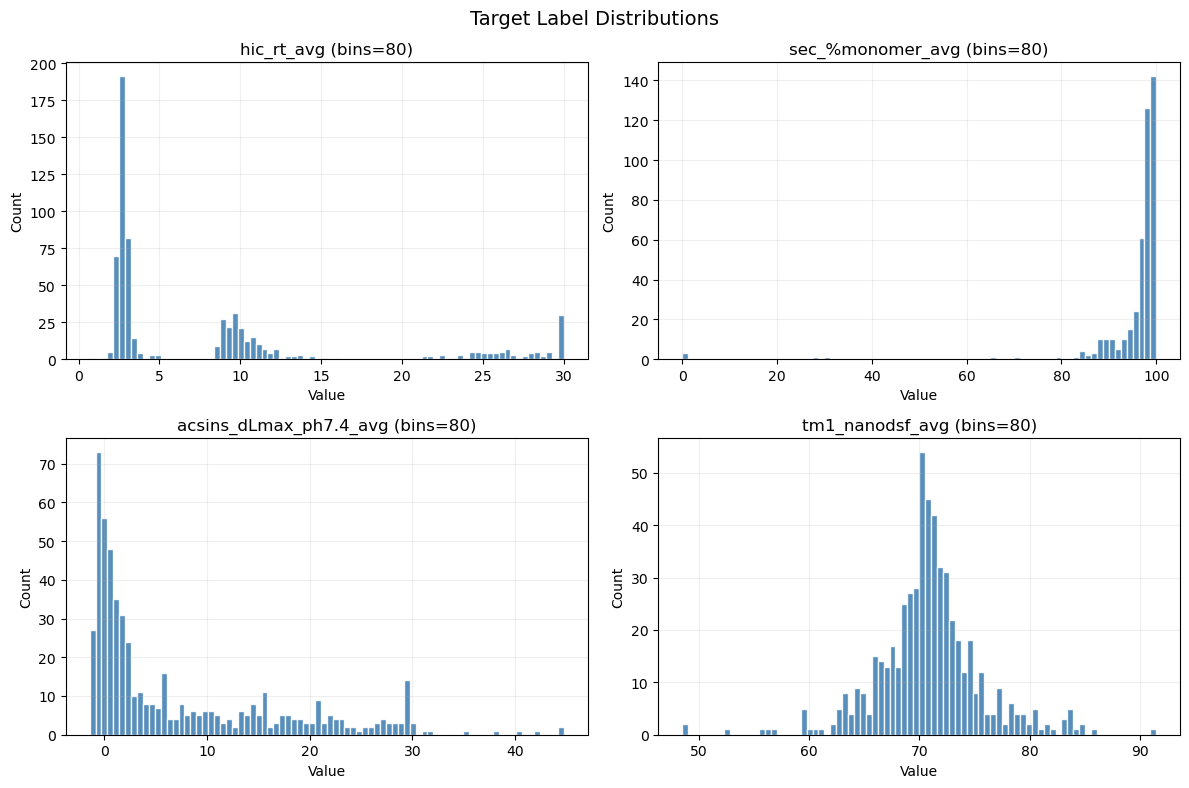

In [18]:
missing_cols = [col for col in target_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f'Missing target columns in dataset: {missing_cols}')

plot_df = df[target_cols].apply(pd.to_numeric, errors='coerce')
valid_counts = plot_df.notna().sum().sort_values(ascending=False)
display(valid_counts.rename('non_null_count').to_frame())

n_targets = len(target_cols)
ncols = 2
nrows = (n_targets + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, target_cols):
    series = plot_df[col].dropna()
    bins = bins_by_target.get(col, default_bins)
    ax.hist(series, bins=bins, color='steelblue', edgecolor='white', alpha=0.9)
    ax.set_title(f'{col} (bins={bins})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.2)

for ax in axes_flat[n_targets:]:
    ax.set_visible(False)

fig.suptitle('Target Label Distributions', fontsize=14)
fig.tight_layout()
plt.show()
